## Notebook to show Greeks
(implemented in Black_Scholes.py)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import black_scholes as bs

### Parameters

In [2]:
K     = 100.0
r     = 0.03
q     = 0.01
sigma = 0.20
T     = 1.0

spots     = np.linspace(50, 150, 300)
maturites = [1/12, 0.5, 2.0]

print(f"call ATM = {bs.price(K, K, r, q, sigma, T, 'call'):.4f}")

call ATM = 8.8273


## Fonction d'affichage

Fonction commune pour plot les courbes des Greeks

In [3]:
def tracer_greek(fonction_greek, titre, maturites=maturites, kind="call",ligne_zero=True):
    """Trace un Greek en fonction du spot, une courbe par maturite."""
    signe = 1 if kind == "call" else -1
    plt.figure()
    for i in maturites:
        valeurs = fonction_greek(spots, K, r, q, sigma, i, kind)
        courbe, = plt.plot(spots, valeurs,label=f"T = {i: .2f} an")
        plt.axhline(signe*np.exp(-q*i),color=courbe.get_color(),linestyle="--")
    plt.title(titre)
    plt.xlabel(f'spot, avec strike = {K}')
    plt.ylabel('Delta')
    plt.axvline(K,color="grey",linestyle="--")
    plt.axhline(0.5*signe,color="grey",linestyle="--")
    plt.legend()
    plt.show()

## Delta

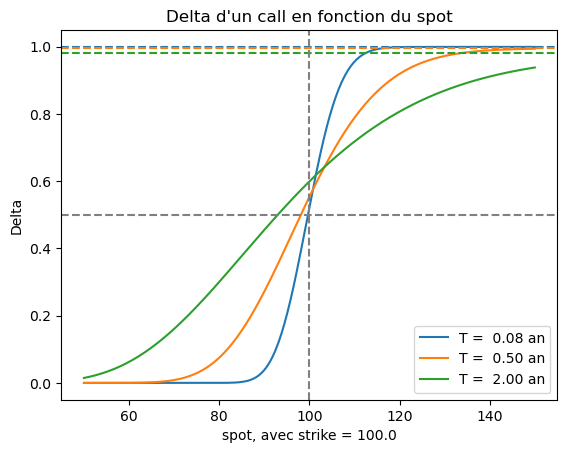

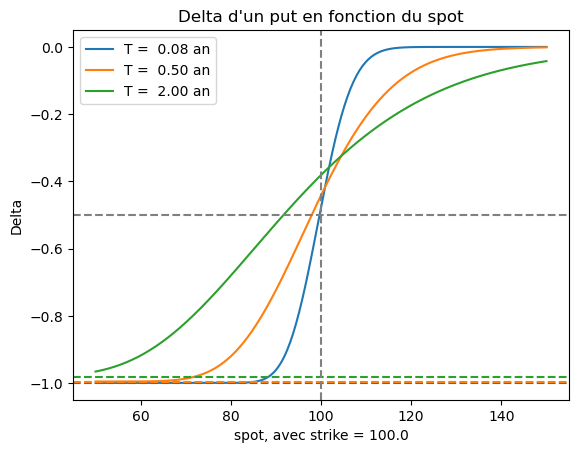

In [4]:
tracer_greek(bs.delta,titre = "Delta d'un call en fonction du spot",kind="call")
tracer_greek(bs.delta,titre = "Delta d'un put en fonction du spot",kind="put")

On observe que : 
- quel que soit la maturité, chaque call reste bien entre 0 et e^-qT pour un call et 0 et -e^-qT pour un put
- Le spot nécessaire pour être à 0.5 de delta pour un call (ou -0.5 pour un put) est toujours plus bas que le strike, ce qui est est normal étant donné que on a ici dans notre exemple r>q (donc forward>spot) et que l'option doit être à la monnaie forward (et donc spot en dessous du strike), et aussi un peu induit par la convexité log normale (terme en sigma^2*T/2)
- le spot nécessaire pour 0.5 delta s'éloigne de plus en plus du strike à mesure que la maturité T grandit. Expliqué par le terme sigma^2*T/2

l'écart entre le delta_call et le delta_put et sa valeur théorique est de :  1.11e-16


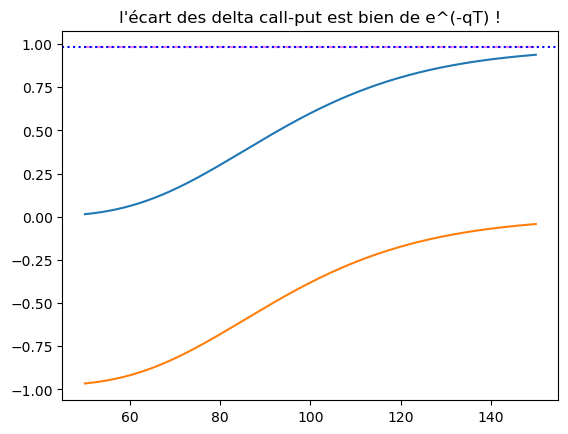

In [5]:
T_fixe = 2
delta_call = bs.delta(spots,K,r,q,sigma,T_fixe,kind="call")
plt.plot(spots,delta_call)
delta_put = bs.delta(spots,K,r,q,sigma,T_fixe,kind="put")
plt.plot(spots,delta_put)
ecart = delta_call - delta_put
plt.plot(spots,ecart,color="violet",linestyle="--")
plt.axhline(np.exp(-q*T_fixe),color="blue",linestyle=":")
plt.title("l'écart des delta call-put est bien de e^(-qT) !")
print(f"l'écart entre le delta_call et le delta_put et sa valeur théorique est de : {np.max(np.abs(ecart-np.exp(-q*T_fixe))): .2e}")

## Gamma

In [6]:
def tracer_greek_2(fonction_greek, titre, maturites=maturites, kind="call",ligne_zero=True,ylabel='Gamma',h_line=False):  #quelques modif pour Gamma
    signe = 1 if kind == "call" else -1
    plt.figure()
    for i in maturites:
        valeurs = fonction_greek(spots, K, r, q, sigma, i, kind)
        courbe, = plt.plot(spots, valeurs,label=f"T = {i: .2f} an")
    plt.title(titre)
    plt.xlabel(f'spot, avec strike = {K}')
    plt.ylabel(ylabel)
    plt.axvline(K,color="grey",linestyle="--")
    if h_line==True:
        plt.axhline(0,color="grey",linestyle="--")
    plt.legend()
    plt.show()

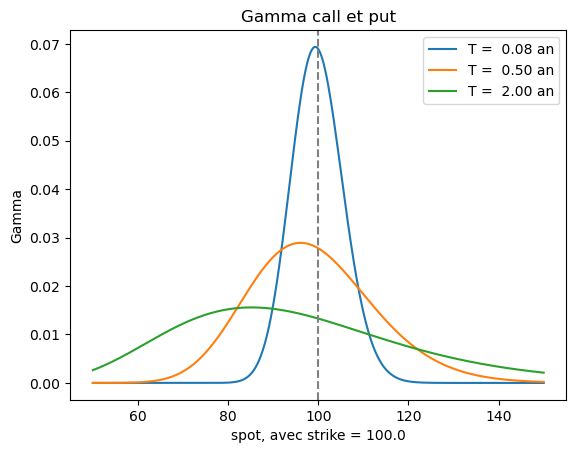

In [7]:
tracer_greek_2(bs.gamma,"Gamma call et put")


On observe que : 
- comme le spot de delta 0.5, le spot de Gamma maximal diminue par rapport au strike à mesure que T et sigma augmentent.
- Le gamma est bien plus grand et plus resséré avec des maturités plus faibles : normal car sqrt(T) est au dénominateur du gamma
### Spot à Gamma maximal :
 

In [8]:
for i in maturites: 
    gamma_call_put = bs.gamma(spots, K, r, q, sigma, i,kind="call")
    print(f"Spot à Gamma Maximal pour la maturité {i: .2f} est : {spots[np.argmax(gamma_call_put)]: .3f}")

Spot à Gamma Maximal pour la maturité  0.08 est :  99.498
Spot à Gamma Maximal pour la maturité  0.50 est :  96.154
Spot à Gamma Maximal pour la maturité  2.00 est :  85.117


Donc on un ici trouvé les spots à Gamma Max

## Vega

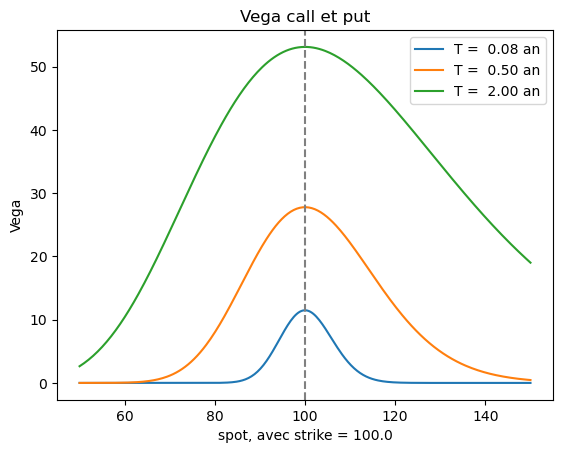

In [9]:
tracer_greek_2(bs.vega,"Vega call et put",ylabel='Vega')


On observe bien que : 
- contrairement au gamma, le vega augmente avec la maturité, ce qui est logique 
- QUe le vega est parfaitement symétrique et maximal à spot = strike
- 

## Theta

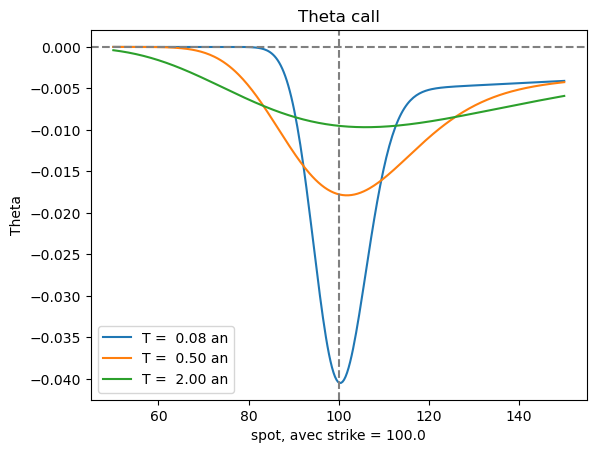

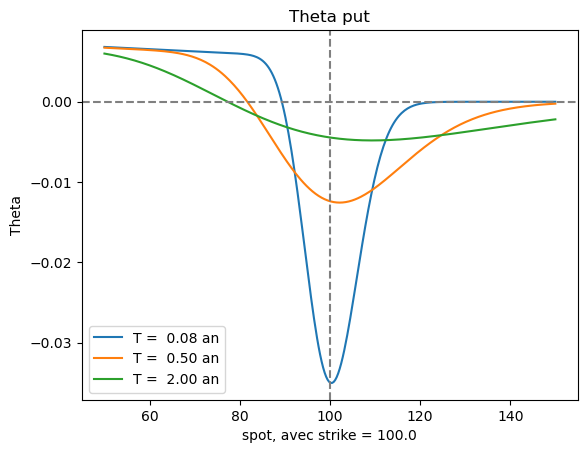

In [10]:
tracer_greek_2(bs.theta,"Theta call",ylabel='Theta',kind="call",h_line=True)
tracer_greek_2(bs.theta,"Theta put",ylabel='Theta',kind="put",h_line=True)



On remarque bien que : 
- le theta est toujours le plus négatif à la monnaie (on peut perdre le plus quand on est à la monnaie pour chaque jour qui passe)
- Le theta est grand est resséré lorsque les maturités sont faibles, ce qui cohérent
- Surtout, on remarque que le theta du put peut être négatif : pour un spot bas ici (donc put depp-in-the-monney).Cela est du au fait que pour un put deep-in-the-monney, sa valeur est presque  K·e^(-rT) moins S. Le détenteur va recevoir K à maturité, et cette somme s'actualise plus vite que la perte de valeur temps, donc le détenteur gagne à attendre.
- Il est aussi possible que le theta d'un call soit positif avec `q>>r`

Tout cela se résume par la relation de Black_Scholes reliant Gamma et Theta et Delta : 

$$\Theta + (r - q) S \Delta + \tfrac{1}{2} \sigma^2 S^2 \Gamma = r V$$

Et si on est Delta neutre ça se simplifie en : 
$$\Theta + \tfrac{1}{2} \sigma^2 S^2 \Gamma = r V$$

### Example de Theta call positif

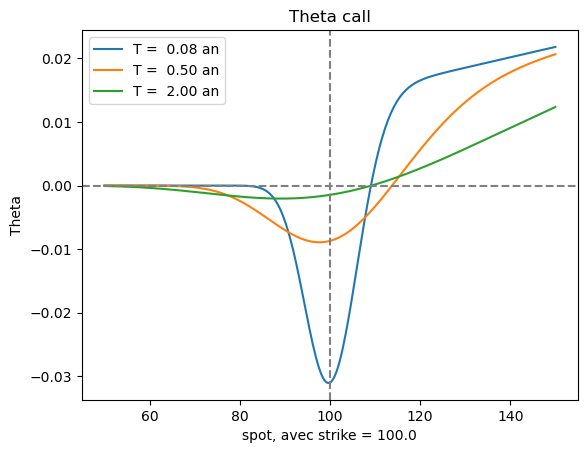

In [11]:
r     = 0.01
q     = 0.06
tracer_greek_2(bs.theta,"Theta call",ylabel='Theta',kind="call",h_line=True)

## Rho

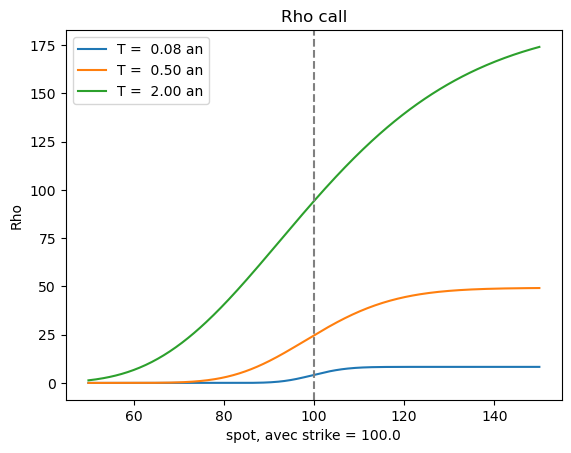

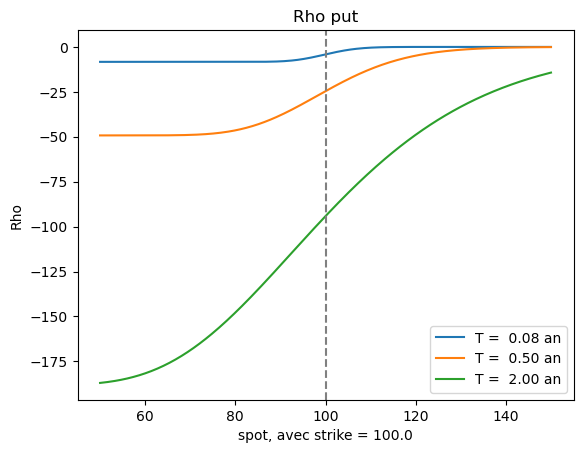

In [12]:
r     = 0.03
q     = 0.01
tracer_greek_2(bs.rho,"Rho call",ylabel='Rho',kind="call")
tracer_greek_2(bs.rho,"Rho put",ylabel='Rho',kind="put")



On remaque que : 
- Le rho croit énormément avec les maturités longues (c'est logique), et il est presque négligeable pour des options courtes, sur 1 mois par exemple.
- Le rho d'un call est toujours positif : car le coût du call pour l'investisseur est K*e^-rT, donc coût moins avec une hausse des taux. Un call deep-in-the-money sera très probablement exercé, d'où la croissance de la courbe. Et inversement pour un put
- Autre remarque : le rho suppose un courbe des taux qui bouge uniformément toutes maturité confondues. C'est un peu grossier car ce n'est pas le cas en réalité. C'est une limite de ce greek.